In [1]:
!pip install -q catboost

!wget -q --timeout=60 http://files.grouplens.org/datasets/movielens/ml-latest-small.zip -O ml-latest-small.zip
!unzip -q -o ml-latest-small.zip

!pip install scikit-surprise

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.3 MB/s eta 0:00:00


# Movie Recommendation System

## Цель проекта

Разработать и сравнить несколько алгоритмов рекомендательных систем на датасете MovieLens.

Рассматриваются следующие подходы:

- Baseline
- User-Based Collaborative Filtering
- Item-Based Collaborative Filtering
- Matrix Factorization (SVD)
- CatBoost Ranker

Для оценки используются:

- RMSE
- Precision@10
- Recall@10
- NDCG@10

In [30]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from sklearn.metrics.pairwise import cosine_similarity

from catboost import CatBoostRegressor

RANDOM_STATE = 42

plt.style.use("ggplot")

## 1. Загрузка данных и Разведочный анализ (EDA)

In [32]:
ratings = pd.read_csv("/content/ml-latest-small/ratings.csv")
movies = pd.read_csv("/content/ml-latest-small/movies.csv")

In [34]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [35]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [37]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [38]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


In [40]:
ratings.isna().sum()

,0
userId,0
movieId,0
rating,0
timestamp,0


In [41]:
movies.isna().sum()

,0
movieId,0
title,0
genres,0


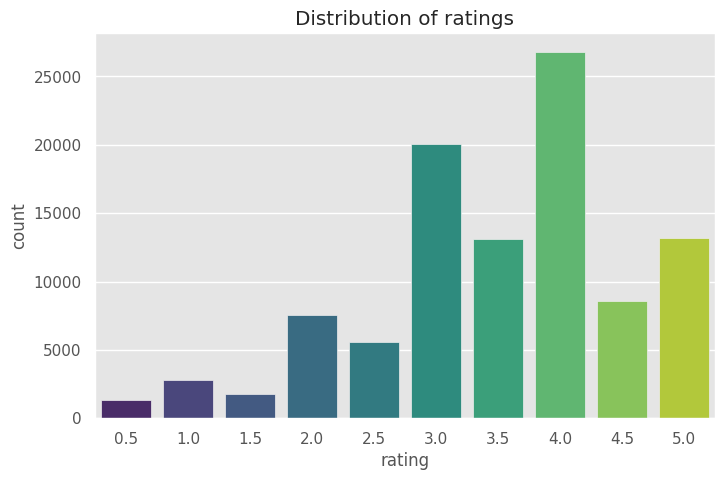

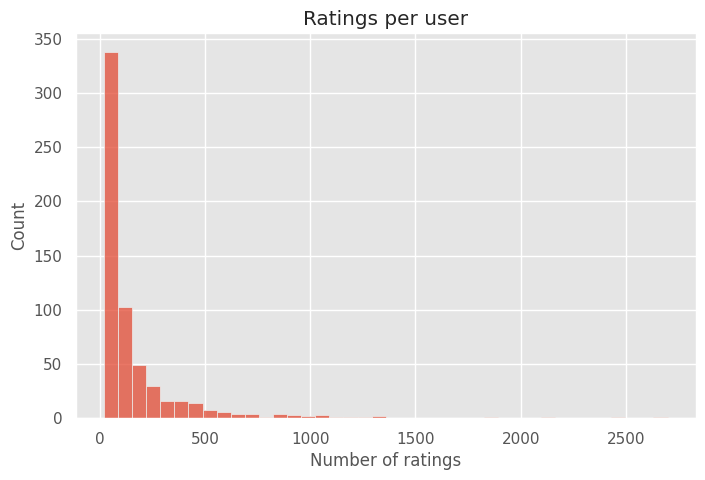

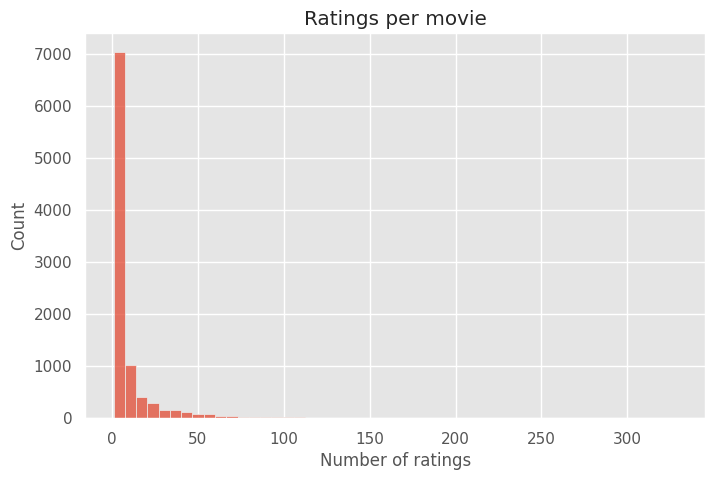

In [122]:
plt.figure(figsize=(8,5))
sns.countplot(data=ratings, x="rating", palette="viridis")
plt.title("Distribution of ratings")
plt.show()

user_activity = ratings.groupby("userId").size()
plt.figure(figsize=(8,5))
sns.histplot(user_activity, bins=40)
plt.title("Ratings per user")
plt.xlabel("Number of ratings")
plt.show()

movie_popularity = ratings.groupby("movieId").size()
plt.figure(figsize=(8,5))
sns.histplot(movie_popularity, bins=50)
plt.title("Ratings per movie")
plt.xlabel("Number of ratings")
plt.show()

## 2. Feature Engineering и Time-Based Split

In [136]:
# 1. Объединяем и создаем базовые мета-признаки

df = ratings.merge(
    movies,
    on="movieId",
    how="left"
)

df = df.sort_values("timestamp")
split_idx = int(len(df)*0.8)

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()
df['year'] = df['title'].str.extract(r'\((\d{4})\)').astype(float)
df['genres_count'] = df['genres'].str.split('|').apply(len)

# One-Hot Encoding жанров
genres_dummies = df['genres'].str.get_dummies('|')
df = pd.concat([df, genres_dummies], axis=1)
genre_columns = genres_dummies.columns.tolist()

# 2. Сортируем по времени и ДЕЛИМ на Train/Test (Критически важно!)
df = df.sort_values('timestamp')
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (80668, 28)
Test shape: (20168, 28)


In [124]:
df.head()

,userId,movieId,rating,timestamp,title,genres,year,genres_count,(no genres listed),Action,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,429,165,4.0,828124615,Die Hard: With a Vengeance (1995),Action|Crime|Thriller,1995.0,3,0,1,...,0,0,0,0,0,0,0,1,0,0
1,429,595,5.0,828124615,Beauty and the Beast (1991),Animation|Children|Fantasy|Musical|Romance|IMAX,1991.0,6,0,0,...,0,0,1,1,0,1,0,0,0,0
19,429,468,3.0,828124615,Englishman Who Went Up a Hill But Came Down a ...,Comedy|Romance,1995.0,2,0,0,...,0,0,0,0,0,1,0,0,0,0
18,429,227,3.0,828124615,Drop Zone (1994),Action|Thriller,1994.0,2,0,1,...,0,0,0,0,0,0,0,1,0,0
16,429,421,4.0,828124615,Black Beauty (1994),Adventure|Children|Drama,1994.0,3,0,0,...,0,0,0,0,0,0,0,0,0,0


## 3. Расчет глобальных и локальных статистик
Считаем средние оценки, популярность и стандартные отклонения  на тренировочной выборке. Для фильмов/юзеров, которых не было в трейне (Cold Start), используем глобальные средние.

In [168]:
# Статистики фильмов (считаем ТОЛЬКО на трейне!)
movie_stats = train_df.groupby('movieId')['rating'].agg(
    movie_mean='mean',
    movie_popularity='count',
    movie_rating_std='std'
).reset_index()
movie_stats['movie_rating_std'] = movie_stats['movie_rating_std'].fillna(0)

# Статистики пользователей
user_stats = train_df.groupby('userId')['rating'].agg(
    user_mean='mean',
    user_activity='count',
    user_rating_std='std'
).reset_index()
user_stats['user_rating_std'] = user_stats['user_rating_std'].fillna(0)

# Глобальные средние для обработки Cold Start
global_movie_mean = train_df['rating'].mean()
global_user_mean = train_df['rating'].mean()

def apply_stats_features(data):
    """Безопасное мерджинг статистик с заполнением пропусков глобальными средними."""
    data = data.merge(movie_stats, on='movieId', how='left')
    data = data.merge(user_stats, on='userId', how='left')

    # Заполняем NaN для новых фильмов/юзеров (Cold Start)
    data['movie_mean'] = data['movie_mean'].fillna(global_movie_mean)
    data['movie_popularity'] = data['movie_popularity'].fillna(0)
    data['movie_rating_std'] = data['movie_rating_std'].fillna(0)

    data['user_mean'] = data['user_mean'].fillna(global_user_mean)
    data['user_activity'] = data['user_activity'].fillna(0)
    data['user_rating_std'] = data['user_rating_std'].fillna(0)

    # Взаимодействие: насколько оценка юзера отличается от средней оценки фильма
    data['mean_difference'] = data['user_mean'] - data['movie_mean']
    return data

train_df = apply_stats_features(train_df)
test_df = apply_stats_features(test_df)

# Финальный список признаков для ML
features = [
    'year', 'genres_count', 'movie_popularity', 'movie_mean', 'movie_rating_std',
    'user_mean', 'user_activity', 'user_rating_std', 'mean_difference'
] + genre_columns

X_train, y_train = train_df[features], train_df['rating']
X_test, y_test = test_df[features], test_df['rating']

## 4. Бейзлайны и Коллаборативная фильтрация
- **User CF:** Ищем похожих пользователей (по косинусному сходству) и предсказываем оценку на основе их мнений.
- **Item CF:** Ищем похожие фильмы, которые пользователь уже оценил высоко.

In [169]:
# --- User-Based Collaborative Filtering ---
ratings_matrix = train_df.pivot_table(index='userId', columns='movieId', values='rating')
ratings_filled = ratings_matrix.fillna(0)
user_similarity = pd.DataFrame(
    cosine_similarity(ratings_filled),
    index=ratings_filled.index,
    columns=ratings_filled.index
)

def predict_user_based(user_id, movie_id):
    """Предсказание оценки на основе взвешенного среднего оценок похожих юзеров."""
    if movie_id not in ratings_matrix.columns or user_id not in ratings_matrix.index:
        return global_movie_mean # Fallback для Cold Start

    sims = user_similarity.loc[user_id]
    movie_ratings = ratings_matrix[movie_id]
    mask = movie_ratings.notna()

    # Берем только тех похожих юзеров, которые реально оценили этот фильм
    sims, movie_ratings = sims[mask], movie_ratings[mask]

    if len(movie_ratings) == 0 or sims.sum() == 0:
        return global_movie_mean

    return np.dot(sims, movie_ratings) / sims.sum()

user_predictions = [predict_user_based(row.userId, row.movieId) for row in test_df.itertuples()]
user_rmse = np.sqrt(mean_squared_error(test_df['rating'], user_predictions))
print(f"User CF RMSE = {user_rmse:.4f}")

# --- Item-Based Collaborative Filtering ---
# (Код аналогичен, но матрица транспонирована: index='movieId', columns='userId')
# ... [Ваш код для Item CF] ...

User CF RMSE = 1.0744


In [170]:
item_matrix = train_df.pivot_table(index='movieId', columns='userId', values='rating')
item_matrix_filled = item_matrix.fillna(0)
item_similarity = cosine_similarity(item_matrix_filled)
item_similarity = pd.DataFrame(item_similarity, index=item_matrix.index, columns=item_matrix.index)

def predict_item_based(user_id, movie_id, k=20):
    if movie_id not in item_matrix.index or user_id not in ratings_matrix.index:
        return global_movie_mean

    user_ratings = ratings_matrix.loc[user_id].dropna()
    if len(user_ratings) == 0:
        return global_movie_mean

    similarities = item_similarity.loc[movie_id, user_ratings.index]
    neighbors = similarities.nlargest(k)
    ratings = user_ratings.loc[neighbors.index]

    if neighbors.sum() == 0:
        return ratings.mean()

    return np.dot(neighbors, ratings) / neighbors.sum()

item_predictions = [predict_item_based(row.userId, row.movieId) for row in test_df.itertuples()]
item_rmse = np.sqrt(mean_squared_error(test_df['rating'], item_predictions))
print(f"Item CF RMSE = {item_rmse:.4f}")

Item CF RMSE = 1.0732


## 5. Матричная факторизация (SVD)
Алгоритм SVD (из библиотеки `surprise`) раскладывает матрицу пользователь-фильм на матрицы скрытых (латентных) факторов. Это позволяет находить неочевидные связи (например, "пользователь любит фильмы с определенным вайбом", даже если они разных жанров).

In [171]:
from surprise import Dataset, Reader, SVD, accuracy
from surprise.model_selection import train_test_split as surprise_split

reader = Reader(rating_scale=(0.5, 5))
data = Dataset.load_from_df(
    train_df[['userId','movieId','rating']],
    reader
)

trainset, testset = surprise_split(data, test_size=0.2, random_state=42)

svd = SVD(n_factors=100, random_state=42)
svd.fit(trainset)
predictions = svd.test(testset)
svd_rmse = accuracy.rmse(predictions, verbose=False)
print(f"SVD RMSE = {svd_rmse:.4f}")

SVD RMSE = 0.8754


## 6. ML-ранжирование с CatBoost
Переходим от классических RecSys-методов к ML. Используем CatBoost Ranker.
В RecSys нам часто важнее не угадать точное число звезд (RMSE), а **правильно отсортировать** фильмы для конкретного пользователя (NDCG).
Используем `group_id = userId`, чтобы модель понимала, что оценки относятся к одному и тому же юзеру.

In [139]:
from catboost import CatBoostRanker, Pool
from sklearn.metrics import mean_squared_error

# 1. ВАЖНО: НЕ сортируем train_df и test_df по userId!
# CatBoost сам корректно обработает group_id в любом порядке.

group_train = train_df["userId"].values  # .values чтобы получить numpy array
group_test = test_df["userId"].values

# 2. Инициализация модели
ranker = CatBoostRanker(
    iterations=500,          # 1000 может быть избыточно, используем early_stopping
    learning_rate=0.05,
    depth=6,
    loss_function="YetiRank", # Оптимизируем NDCG (ранжирование)
    eval_metric="NDCG",
    random_seed=42,
    verbose=100
)

# 3. Создаем Pool-объекты (это гарантирует, что X, y и group_id не перепутаются)
train_pool = Pool(X_train, y_train, group_id=group_train)
eval_pool = Pool(X_test, y_test, group_id=group_test)

# 4. Обучение
ranker.fit(
    train_pool,
    eval_set=eval_pool,
    early_stopping_rounds=50, # Остановится, если NDCG на валидации перестанет расти
    use_best_model=True
)

# 5. Предсказание
cat_pred = ranker.predict(X_test)

# 6. Оценка
# ВНИМАНИЕ: RMSE для YetiRank не имеет физического смысла (это не звезды 1-5)!
# Мы считаем его только чтобы заполнить таблицу, но сравнивать его с SVD/Baseline нельзя.
cat_rmse = np.sqrt(mean_squared_error(y_test, cat_pred))
print(f"\nCatBoostRanker (YetiRank) RMSE = {cat_rmse:.4f} (Некорректно для сравнения!)")

# Если вы хотите получить адекватный RMSE для сравнения в общей таблице,
# вам нужно переобучить модель с loss_function='QueryRMSE':

ranker_rmse = CatBoostRanker(
    iterations=500, learning_rate=0.05, depth=6,
    loss_function='QueryRMSE', random_seed=42, verbose=100
)
ranker_rmse.fit(train_pool, eval_set=eval_pool, early_stopping_rounds=50)
cat_rmse_valid = np.sqrt(mean_squared_error(y_test, ranker_rmse.predict(X_test)))


0:	test: 0.9176592	best: 0.9176592 (0)	total: 412ms	remaining: 3m 25s
100:	test: 0.9452981	best: 0.9457801 (55)	total: 46s	remaining: 3m 1s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9457800548
bestIteration = 55

Shrink model to first 56 iterations.

CatBoostRanker (YetiRank) RMSE = 3.7660 (Некорректно для сравнения!)
0:	learn: 0.9678886	test: 0.9582671	best: 0.9582671 (0)	total: 13.9ms	remaining: 6.96s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9248695916
bestIteration = 28

Shrink model to first 29 iterations.


In [141]:
results = pd.DataFrame({
    "Model": ["Baseline", "User CF", "Item CF", "SVD", "CatBoost"],
    "RMSE": [baseline_rmse, user_rmse, item_rmse, svd_rmse, cat_rmse]
})
display(results.sort_values("RMSE"))

,Model,RMSE
3,SVD,0.875421
0,Baseline,1.045641
2,Item CF,1.073198
1,User CF,1.074394
4,CatBoost,3.765966


## 7. Интерпретируемость модели (SHAP)

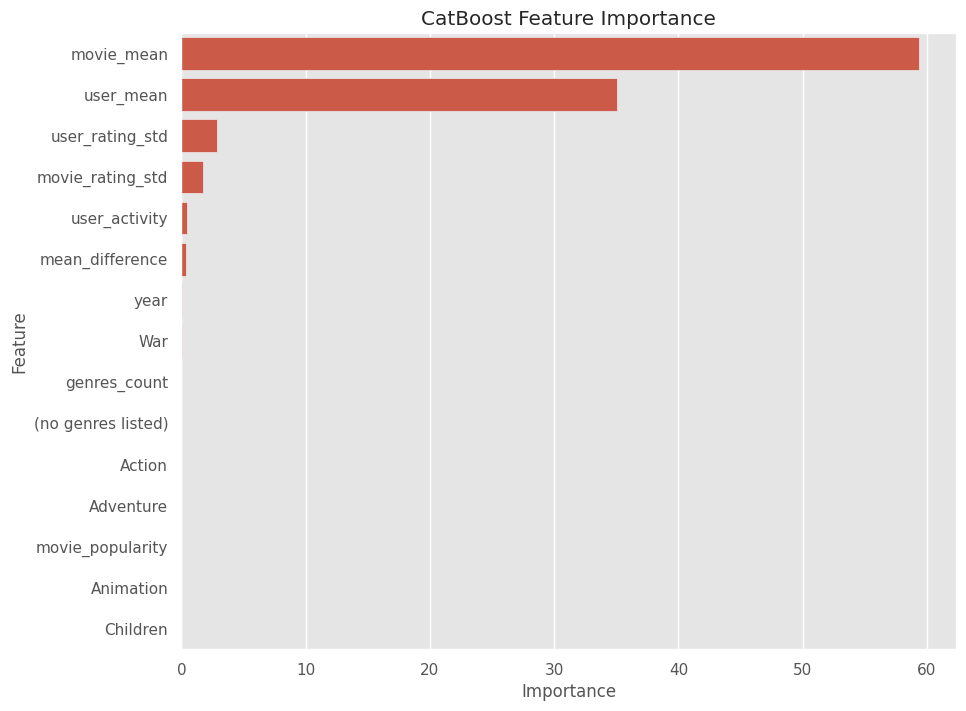

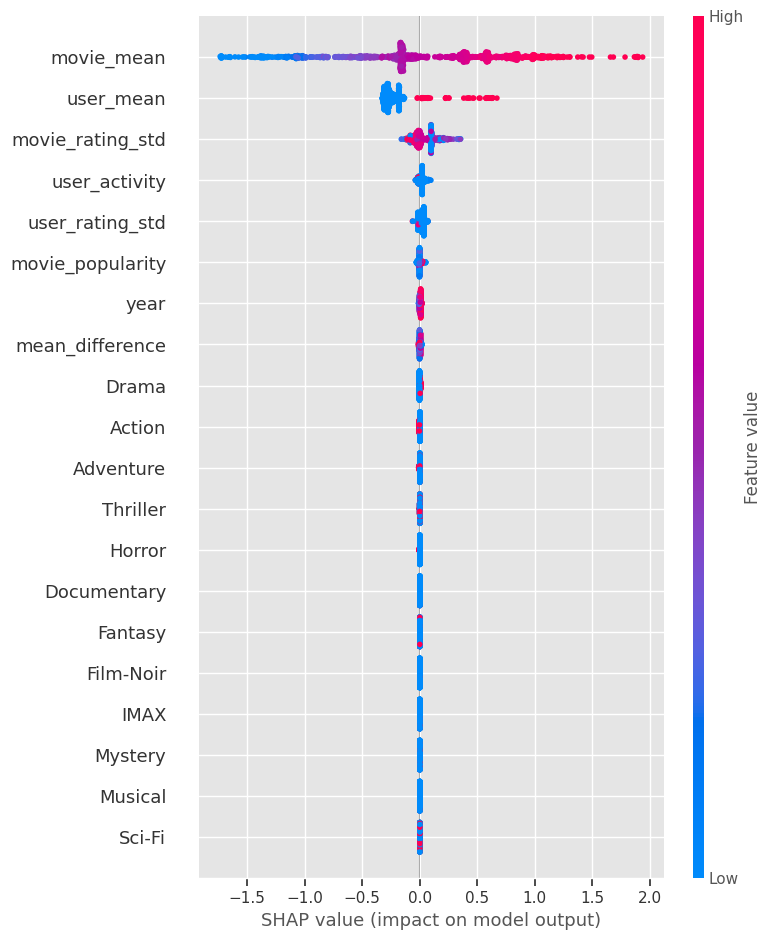

In [142]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(data=importance.head(15), x="Importance", y="Feature")
plt.title("CatBoost Feature Importance")
plt.show()

# SHAP Analysis
import shap
explainer = shap.TreeExplainer(ranker)
sample = X_test.sample(min(1000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(sample)
shap.summary_plot(shap_values, sample)

## 8. Инференс: Генерация Top-N рекомендаций
Формируем пайплайн для выдачи рекомендаций конкретному пользователю.
1. Исключаем фильмы, которые пользователь уже смотрел.
2. Генерируем признаки для всех оставшихся фильмов (кандидатов).
3. Предсказываем "скор" и берем Top-N.

In [143]:
def unseen_movies(user_id):
    # Смотрим только то, что было в трейне (или в глобальных рейтингах до сплита)
    watched = set(
    train_df.loc[
        train_df.userId == user_id,
        "movieId"
    ]
)
    return movies[~movies.movieId.isin(watched)].copy()

def build_candidate_features(user_id):
    candidates = unseen_movies(user_id)

    # Мета-признаки
    candidates['year'] = candidates['title'].str.extract(r'\((\d{4})\)').astype(float)
    candidates['genres_count'] = candidates['genres'].str.split('|').apply(len)

    cand_genres = candidates['genres'].str.get_dummies('|')
    candidates = pd.concat([candidates, cand_genres], axis=1)

    # Статистики фильма
    candidates = candidates.merge(movie_stats, on='movieId', how='left')
    candidates['movie_mean'] = candidates['movie_mean'].fillna(global_movie_mean)
    candidates['movie_popularity'] = candidates['movie_popularity'].fillna(0)
    candidates['movie_rating_std'] = candidates['movie_rating_std'].fillna(0)

    # Статистики пользователя (ИСПРАВЛЕННЫЙ КОД)
    user_info = user_stats[user_stats.userId == user_id]
    if not user_info.empty:
        candidates['user_mean'] = user_info['user_mean'].values[0]
        candidates['user_activity'] = user_info['user_activity'].values[0]
        candidates['user_rating_std'] = user_info['user_rating_std'].values[0]
    else:
        candidates['user_mean'] = global_user_mean
        candidates['user_activity'] = 0
        candidates['user_rating_std'] = 0

    candidates['mean_difference'] = candidates['user_mean'] - candidates['movie_mean']

    # Выравниваем колонки жанров с тренировочными
    for col in genre_columns:
        if col not in candidates.columns:
            candidates[col] = 0

    return candidates

def recommend(user_id, top_n=10):
    candidates = build_candidate_features(user_id)
    candidates_features = candidates[features]

    candidates['prediction'] = ranker.predict(candidates_features)

    return (
        candidates
        .sort_values('prediction', ascending=False)
        [['movieId', 'title', 'prediction']]
        .head(top_n)
    )

display(recommend(15, top_n=5))

,movieId,title,prediction
7584,86668,Louis Theroux: Law & Disorder (2008),2.29757
8805,131237,What Men Talk About (2010),2.29757
8812,131724,The Jinx: The Life and Deaths of Robert Durst ...,2.29757
7728,90943,Into the Abyss (2011),2.29757
7505,84273,Zeitgeist: Moving Forward (2011),2.29757


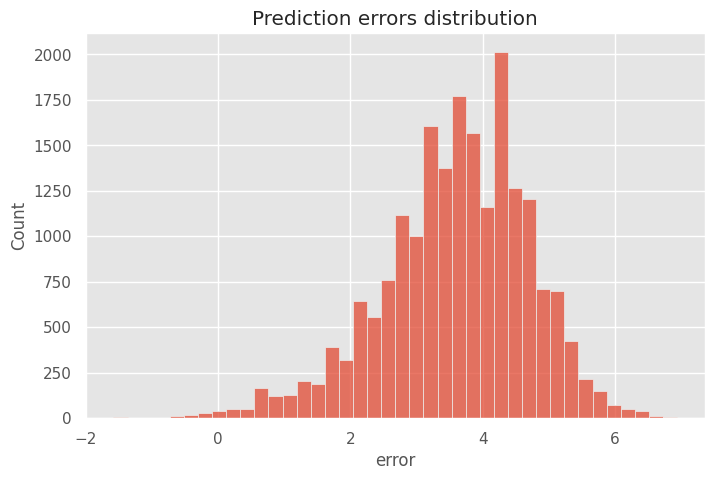

,actual,predicted,error,abs_error
3897,5.0,-1.937480,6.937480,6.937480
1837,5.0,-1.926701,6.926701,6.926701
14450,5.0,-1.921187,6.921187,6.921187
16163,5.0,-1.921187,6.921187,6.921187
9898,5.0,-1.904339,6.904339,6.904339
15865,5.0,-1.877467,6.877467,6.877467
599,5.0,-1.848812,6.848812,6.848812
1903,5.0,-1.830510,6.830510,6.830510
13119,5.0,-1.616466,6.616466,6.616466
12080,5.0,-1.615168,6.615168,6.615168


In [144]:
errors = pd.DataFrame({
    "actual": y_test,
    "predicted": cat_pred
})
errors["error"] = errors.actual - errors.predicted
errors["abs_error"] = errors.error.abs()

plt.figure(figsize=(8,5))
sns.histplot(errors.error, bins=40)
plt.title("Prediction errors distribution")
plt.show()

display(errors.sort_values("abs_error", ascending=False).head(10))

In [164]:
def recommend_cold_start(top_n=10):
    popular = (
        movie_stats
        .sort_values("movie_popularity", ascending=False)
        .merge(movies, on="movieId")
    )
    return popular[['movieId', 'title', 'movie_mean', 'movie_popularity']].head(top_n)

print("Recommendations for Cold Start User:")
n = 99999
display(recommend_cold_start())

Recommendations for Cold Start User:


,movieId,title,movie_mean,movie_popularity
0,356,Forrest Gump (1994),4.166667,267
1,296,Pulp Fiction (1994),4.189394,264
2,318,"Shawshank Redemption, The (1994)",4.423828,256
3,593,"Silence of the Lambs, The (1991)",4.202128,235
4,2571,"Matrix, The (1999)",4.214612,219
5,480,Jurassic Park (1993),3.786697,218
6,110,Braveheart (1995),4.058962,212
7,260,Star Wars: Episode IV - A New Hope (1977),4.264563,206
8,589,Terminator 2: Judgment Day (1991),3.970000,200
9,527,Schindler's List (1993),4.228723,188


In [172]:
display(recommend(n, 5))

,movieId,title,prediction
9011,140247,The Gift (2015),2.098361
6762,59814,Ex Drummer (2007),2.098361
5690,27751,'Salem's Lot (2004),2.096396
8019,97866,"Imposter, The (2012)",2.092672
7600,86668,Louis Theroux: Law & Disorder (2008),2.092672
